In [2]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize()

Gtk-Message: 15:32:25.048: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


Enter verification code:  4/1AdkVLPy-ldxN8-X0TTTtkFh5duJN0QmrB7pjWEKF4kbT0YtPSIUMm2H-6mY



Successfully saved authorization token.


In [3]:
counties = ee.FeatureCollection("FAO/GAUL/2015/level2")

makueni = counties.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"),
        ee.Filter.eq("ADM2_NAME", "Makueni")
    )
)

In [4]:
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()

In [5]:
cropland = worldcover.eq(40).clip(makueni)

In [7]:
Map = geemap.Map(center=[-2.25, 37.9], zoom=9)

Map.addLayer(
    cropland,
    {"min": 0, "max": 1, "palette": ["white", "green"]},
    "Cropland mask"
)

#Map.addLayer(makueni, {"color": "red"}, "Makueni County")

Map

Map(center=[-2.25, 37.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [8]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(makueni)
    .filterDate("2024-01-01", "2024-02-01")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)

image = s2.median().clip(makueni)

ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")

In [9]:
ndvi_cropland = ndvi.updateMask(cropland)

In [10]:
mean_ndvi_all = ndvi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=makueni.geometry(),
    scale=10,
    maxPixels=1e9
)

print("All pixels:", mean_ndvi_all.getInfo())

All pixels: {'NDVI': 0.6316708595939606}


In [11]:
mean_ndvi_cropland = ndvi_cropland.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=makueni.geometry(),
    scale=10,
    maxPixels=1e9
)

print("Cropland only:", mean_ndvi_cropland.getInfo())

Cropland only: {'NDVI': 0.5901088861566655}


In [13]:
Map = geemap.Map(center=[-2.25, 37.9], zoom=9)

ndvi_vis = {
    "min": 0,
    "max": 0.8,
    "palette": ["brown", "yellow", "green"]
}

Map.addLayer(ndvi_cropland, ndvi_vis, "NDVI - Cropland only")
#Map.addLayer(makueni, {"color": "red"}, "Makueni County")

Map

Map(center=[-2.25, 37.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [14]:
print("All pixels:", mean_ndvi_all.getInfo())
print("Cropland only:", mean_ndvi_cropland.getInfo())

All pixels: {'NDVI': 0.6316708595939606}
Cropland only: {'NDVI': 0.5901088861566655}


In [15]:
def monthly_mean_ndvi_cropland(start_date, end_date):
    
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(makueni)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )
    
    image = s2.median().clip(makueni)

    ndvi = image.normalizedDifference(
        ["B8", "B4"]
    ).rename("NDVI")
    
    ndvi_cropland = ndvi.updateMask(cropland)
    
    mean_ndvi = ndvi_cropland.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=makueni.geometry(),
        scale=10,
        maxPixels=1e9
    )

    return mean_ndvi.get("NDVI")

In [16]:
months = pd.date_range(
    start="2023-01-01",
    end="2024-12-01",
    freq="MS"
)

results = []

for start in months:
    end = start + pd.DateOffset(months=1)

    value = monthly_mean_ndvi_cropland(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d")
    ).getInfo()

    results.append({
        "month": start,
        "mean_ndvi_cropland": value
    })

    print(start.strftime("%Y-%m"), value)

2023-01 0.43617542132573284
2023-02 0.26012229878327636
2023-03 0.21953140503494958
2023-04 0.3224234169608575
2023-05 0.2944087342223838
2023-06 0.43505797118517237
2023-07 0.25683409895918846
2023-08 0.21783686279169068
2023-09 0.19466010246697127
2023-10 0.1702020989946899
2023-11 0.43556604724463377
2023-12 0.5231409401879279
2024-01 0.5901088861566655
2024-02 0.38813032754173193
2024-03 0.4255804612603782
2024-04 0.40695278004629004
2024-05 0.552537704188955
2024-06 0.4956357926361103
2024-07 0.24246921811460917
2024-08 0.23260642987600608
2024-09 0.2535702483899385
2024-10 0.2320261042818381
2024-11 0.21491064810378863
2024-12 0.4830455876601432


In [17]:
crop_ndvi_df = pd.DataFrame(results)
crop_ndvi_df.head()

,month,mean_ndvi_cropland
0,2023-01-01,0.436175
1,2023-02-01,0.260122
2,2023-03-01,0.219531
3,2023-04-01,0.322423
4,2023-05-01,0.294409


In [18]:
crop_ndvi_df.to_csv(
    "../outputs/makueni_monthly_ndvi_cropland_2023_2024.csv",
    index=False
)

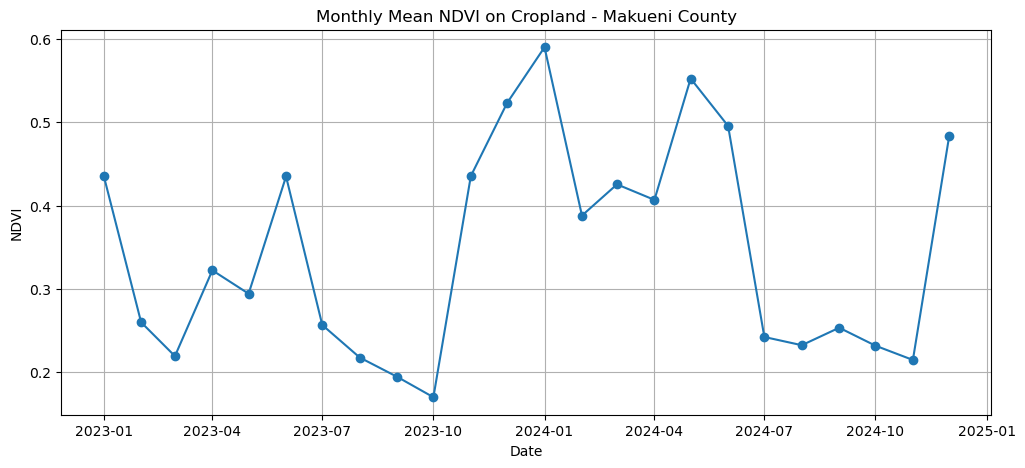

In [19]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    crop_ndvi_df["month"],
    crop_ndvi_df["mean_ndvi_cropland"],
    marker="o"
)

ax.set_title("Monthly Mean NDVI on Cropland - Makueni County")
ax.set_ylabel("NDVI")
ax.set_xlabel("Date")
ax.grid(True)

fig.savefig(
    "../docs/images/makueni_ndvi_cropland_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()